In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sbi.utils as utils
import torch
from scipy.special import logsumexp
from scipy.optimize import minimize
from tqdm import tqdm

class CollectivePosterior:
    """
    A class to represent and sample from a collective posterior distribution.

    Parameters:
        prior: Prior distribution object compatible with `torch.distributions`.
        amortized_posterior: Pretrained posterior model (from sbi or other libraries).
        Xs: Set of observed data points.
        log_C: Normalizing constant for the posterior. Default is 1.
        epsilon: Sensitivity parameter, used as a lower bound for posterior probabilities. Default is -10000.
        n_eval: Number of samples used for Monte Carlo estimation. Default is 1e5.
        sample_var: Variance for MCMC-like sampling. Default is 0.05.
        from_sbi: Whether the posterior is from the sbi library. Default is True.
    """
       
    def __init__(self, prior, Xs, amortized_posterior=None, log_C=1, epsilon=-10000, n_eval = int(1e5), sample_var=0.05, posterior_list=[]):
        self.prior = prior 
        self.amortized_posterior = amortized_posterior
        self.Xs = Xs 
        self.log_C = log_C 
        self.epsilon = epsilon 
        self.map = None 
        self.samples = [] 
        self.theta_dim = prior.sample().shape[0]
        self.n_eval = n_eval
        self.sample_var = sample_var 
        self.posterior_list = posterior_list
        
        assert(len(posterior_list) > 0 or amortized_posterior!=None)
    
    def log_prob(self, theta):
        """
        Compute the log probability of the collective posterior for a given parameter set.
        
        Parameters:
            theta (torch.Tensor): Parameter set to evaluate.
        
        Returns:
            torch.Tensor: Log probability of the given parameter set.
        """
        theta = torch.tensor(theta, dtype=torch.float32)
        # allow one-dim tensor for theta
        if len(theta.size()) == 1:
            theta_size = 1
        else:
            theta_size = theta.size()[0]
        
        # get number of reps
        r = len(self.Xs)
        posterior = self.amortized_posterior
            
        # epsilon must be a tensor
        eps = torch.tensor(self.epsilon)
        if type(theta) != type(torch.tensor(4.2)):
            theta = torch.tensor(theta, dtype=torch.float32)
        if len(theta.size()) > 1:
            t = theta.size()[0]
            eps = torch.tensor([eps for i in range(t)])

        # Get log_prob value(s)
        log_probs = torch.empty((theta_size,r))
        for i in range(r):
            if len(self.posterior_list) == 0: # amortized posterior
                log_probs[:,i] = torch.max(eps,self.amortized_posterior.set_default_x(self.Xs[i,:]).log_prob(theta))
            else: # posterior log-prob function only takes theta
                log_probs[:,i] = torch.max(eps,self.posterior_list[i](theta).reshape(theta_size,))

        logpr = self.prior.log_prob(theta).reshape(theta_size,)
        return log_probs.sum(axis=1) + self.log_C - (1-r)*logpr # log rules
    
    def sample(self, n_samples, jump=int(1e4), keep=True, method='rejection'):
        method_dict = {'rejection': self.rejection_sample,'unimodal': self.sample_unimodal}
        return method_dict[method](n_samples, jump, keep)
        
    
    def rejection_sample(self, n_samples, jump=int(1e4), m = 5, keep=True):
        """
        Sample from the collective posterior using rejection sampling.

        Parameters:
            n_samples (int): Number of samples to generate.
            jump (int): Number of prior samples to draw in each batch. Default is 1e5.
            keep (bool): Whether to store the samples in the object. Default is True.
        
        Returns:
            torch.Tensor: Samples from the posterior.
        """
        samples = torch.empty((1, self.theta_dim))
        cur = 0

        with tqdm(total=n_samples, desc="Rejection Sampling") as pbar:
            while cur < n_samples:
                samps = self.prior.sample((jump,))
                prior_probs = self.prior.log_prob(samps)
                probs = torch.log(torch.rand(samps.size()[0]))
                lp = self.log_prob(samps)
                next_idx = (lp - prior_probs) > (probs+m)
                samples_to_add = samps[next_idx]
                samples = torch.cat([samples, samples_to_add])
                cur += next_idx.sum()
                pbar.update(next_idx.sum().item())  # Update the progress bar

        if keep:
            self.samples = samples[1:n_samples+1]

        return samples[1:n_samples+1]
    


    def sample_one(self, jump=int(1e4), keep=False):
        """
        Draw a single sample from the posterior.

        Parameters:
            jump (int): Number of prior samples to draw in each batch. Default is 1e4.
            keep (bool): Whether to store the sample in the object. Default is True.
        
        Returns:
            torch.Tensor: A single sample from the posterior.
        """
        sampled=False
        while not(sampled):
            samps = self.prior.sample((jump,))
            probs = torch.rand(samps.size()[0])
            lp = self.log_prob(samps)
            next_idx = lp > probs
            if next_idx.sum()>0:
                sampled=True
        return samps[next_idx][0]
    
    def sample_around(self, theta, jump=int(1e4)):
        """
        Sample around a given point using a Gaussian proposal.

        Parameters:
            theta (torch.Tensor): Center of the Gaussian proposal.
            jump (int): Number of candidates to sample. Default is 1e4.
        
        Returns:
            tuple: (Accepted samples, new center theta).
        """
        dist =  torch.distributions.multivariate_normal.MultivariateNormal(theta, torch.diag(torch.tensor([self.sample_var]*self.theta_dim)))
        cands = dist.sample((jump,))
        probs = self.log_prob(cands)
        baseline = torch.rand((len(cands),))
        res = cands[probs>baseline]
        new_theta = cands[probs.argmax()]
        return res, new_theta
    
    def sample_unimodal(self, n_samples, jump=int(1e5), keep=True):
        """
        Sample from the posterior using iterative proposals.

        Parameters:
            n_samples (int): Number of samples to generate.
            jump (int): Number of candidates to sample at each iteration. Default is 1e4.
            keep (bool): Whether to store the samples in the object. Default is True.
        
        Returns:
            torch.Tensor: Samples from the posterior.
        """
        theta = self.sample_one(jump, keep=False)
        samples = torch.empty((n_samples, len(theta)))
        cur = 0

        with tqdm(total=n_samples, desc="Sampling") as pbar:
            while cur < n_samples:
                samps, theta = self.sample_around(theta, jump)
                how_many = len(samps)
                if cur + how_many > n_samples:
                    how_many = n_samples - cur
                if how_many > 0:
                    samples[cur:cur + how_many, :] = samps[:how_many, :]
                    cur += how_many
                    pbar.update(how_many)  # Update the progress bar

        if keep:
            self.samples = samples

        return samples
    
    
    def sample_mcmc(self, num_samples, theta_0):
        """
        Sample from the posterior using the Metropolis-Hastings MCMC algorithm.

        Parameters:
            num_samples (int): Number of samples to draw.
            step_size (float): Proposal standard deviation.
            burn_in (int): Number of initial samples to discard. Default is 1000.

        Returns:
            torch.Tensor: Samples from the posterior.
        """
        
        # Initialize
        # theta = self.sample_one()
        step_size = self.sample_var
        theta = theta_0
        samples = []
        sampled = 0
        with tqdm(total=num_samples, desc="MCMC Sampling") as pbar:
            while sampled < num_samples:
                proposal = theta + torch.randn_like(theta) * step_size
                current_log_prob = self.log_prob(theta)
                proposal_log_prob = self.log_prob(proposal)
                acceptance_prob = torch.exp(proposal_log_prob - current_log_prob)

                if torch.rand(1).item() < acceptance_prob.item():
                    theta = proposal
                    samples.append(theta.clone())
                    sampled+=1
                    pbar.update(1)  # Update the progress bar

        return torch.stack(samples)

    
    def get_map(self, n_init=100, keep=True):
        """
        Compute the Maximum A Posteriori (MAP) estimate.

        Parameters:
            keep (bool): Whether to store the MAP estimate in the object. Default is True.
        
        Returns:
            torch.Tensor: MAP estimate of the posterior mode.
        """
        samples = self.samples
        
        if len(self.posterior_list) > 0:
            func = lambda theta: np.array(-1*self.log_prob(theta)).reshape(1,-1) 
        else:
            func = lambda theta: np.array(-1*self.log_prob(theta)) # max(log_prob) = min(-log_prob) + np array for optimizer
        if len(self.samples) > 0:
            x0 = self.samples[self.log_prob(samples).argmax()]
        else:
            samples = self.sample(n_init)
            x0 = self.samples[self.log_prob(samples).argmax()] # get a nice random guess
        x0 = list(x0)
        collective_map = torch.from_numpy(minimize(func, x0, method='Nelder-Mead').x) # Optimization
        if keep:
            self.map = collective_map
        return collective_map

        
    
    
    def get_log_C(self, n_reps=10):
        """
        Estimate the normalizing constant log_C using Monte Carlo integration.

        Parameters:
            n_reps (int): Number of repetitions for averaging. Default is 10.
        
        Returns:
            torch.Tensor: Estimated log_C value.
        """
        eps = torch.tensor(self.epsilon, dtype=torch.float32)
        r = len(self.Xs)
        log_probs = torch.empty((self.n_eval, r))
        res = []
        logdt = torch.log(torch.tensor(self.n_eval, dtype=torch.float32))
        for k in range(n_reps):
            prior_samples = self.prior.sample((self.n_eval,))
            prior_logps = self.prior.log_prob(prior_samples).reshape(len(prior_samples,))
            for i in range(r):
                if len(self.posterior_list) == 0: # amortized posterior
                    posterior_logps = self.amortized_posterior.set_default_x(self.Xs[i,:]).log_prob(prior_samples)
                    log_probs[:,i] = torch.max(eps,posterior_logps)
                else: # posterior log-prob function only takes theta
                    log_probs[:,i] = torch.max(eps,self.posterior_list[i](prior_samples))
                    # log_probs[:,i] = torch.max(self.amortized_posterior.set_default_x(self.Xs[i,:]).log_prob(prior_samples), eps)
            inds = torch.sum(log_probs,-1) -(1-r)*prior_logps -1*logdt
            complete_log_prob = -1*torch.logsumexp(inds ,0)
            res.append(complete_log_prob)

            # print(prior_samples[])

        self.log_C = torch.tensor(res).mean()
        return self.log_C
        


        
    def sample_multimodal(
        self,
        n_samples: int,
        k: int = 10,                     # number of starting centres
        jump: int = 10_000,
        keep: bool = True,
    ):
        """
        Draw `n_samples` points by running `k` independent short explorations.
        Each sub-run starts from a different seed drawn with `sample_one`.

        NOTE: correctness hinges on `sample_one` / `sample_around`
        being proper rejection samplers (see §2 below).
        """
        assert k >= 1, "k must be at least 1"
        per_chain = math.ceil(n_samples / k)          # sub-samples per centre
        all_chunks = []

        with tqdm(total=n_samples, desc="k-chain sampling") as bar:
            for _ in range(k):
                # 1) independent seed
                theta = self.sample_one(jump, keep=False)

                # 2) grow a local cloud around that seed
                chunk = torch.empty((per_chain, self.theta_dim))
                cur = 0
                while cur < per_chain:
                    samps, theta = self.sample_around(theta, jump)
                    take = min(per_chain - cur, samps.size(0))
                    if take:
                        chunk[cur : cur + take] = samps[:take]
                        cur += take
                        bar.update(take)

                all_chunks.append(chunk)

        samples = torch.cat(all_chunks, dim=0)[:n_samples]   # exact count
        if keep:
            self.samples = samples
        return samples


Text(0, 0.5, 'CNV Proportion')

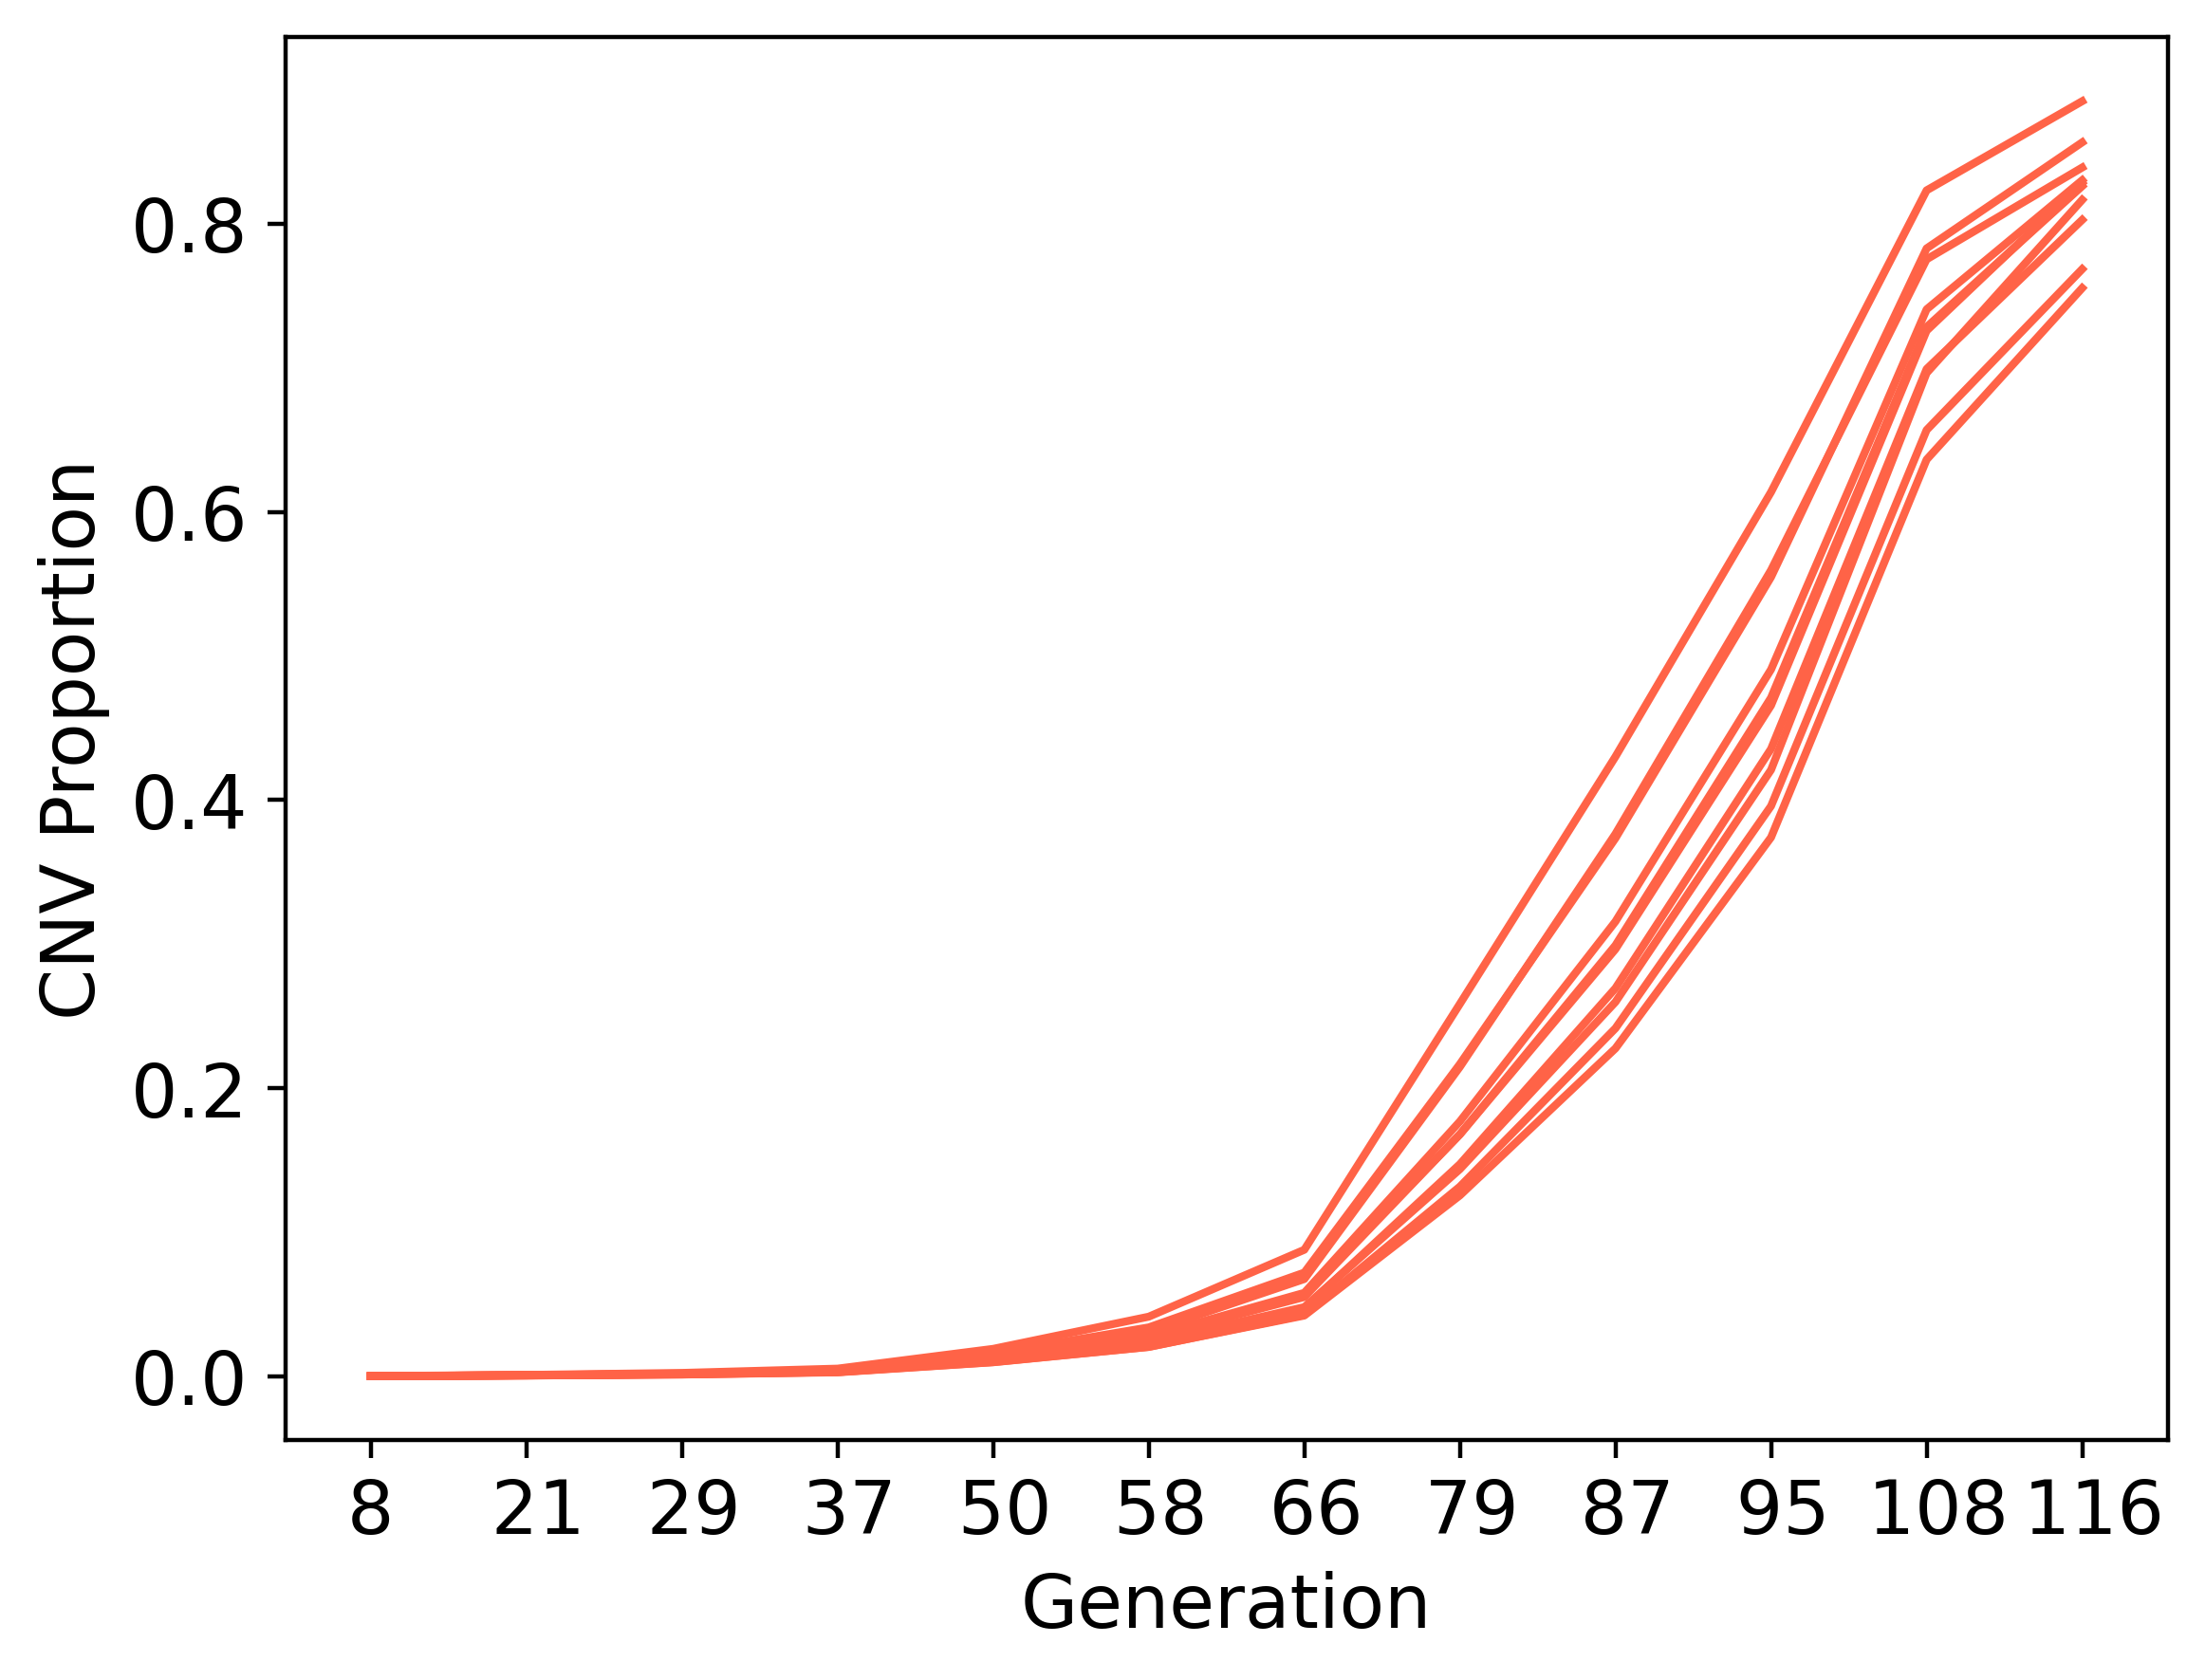

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
import seaborn as sns
from seaborn import kdeplot
import numpy as np
import sys  
sys.path.insert(1, '../')

from simulators import WF, wrapper_hierarchical, wrapper
from seaborn import histplot
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

import warnings
warnings.simplefilter('ignore', Warning)

generation = pd.read_csv('empirical_data/Chuong_116_gens.txt').columns

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize


th = torch.tensor([-1,-5,-5], dtype=torch.float32)
X = wrapper_hierarchical(WF, parameters=th, reps=10) # LTRΔ MAP in paper
change_font(14)

for i in range(len(X)):
    plt.plot(generation,X[i], color='tomato', label='regular' if i==0 else '')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')

k-chain sampling: 100%|██████████| 10000/10000 [00:02<00:00, 3749.17it/s]


CPU times: user 2min 52s, sys: 4.7 s, total: 2min 56s
Wall time: 4.82 s


<Axes: ylabel='Count'>

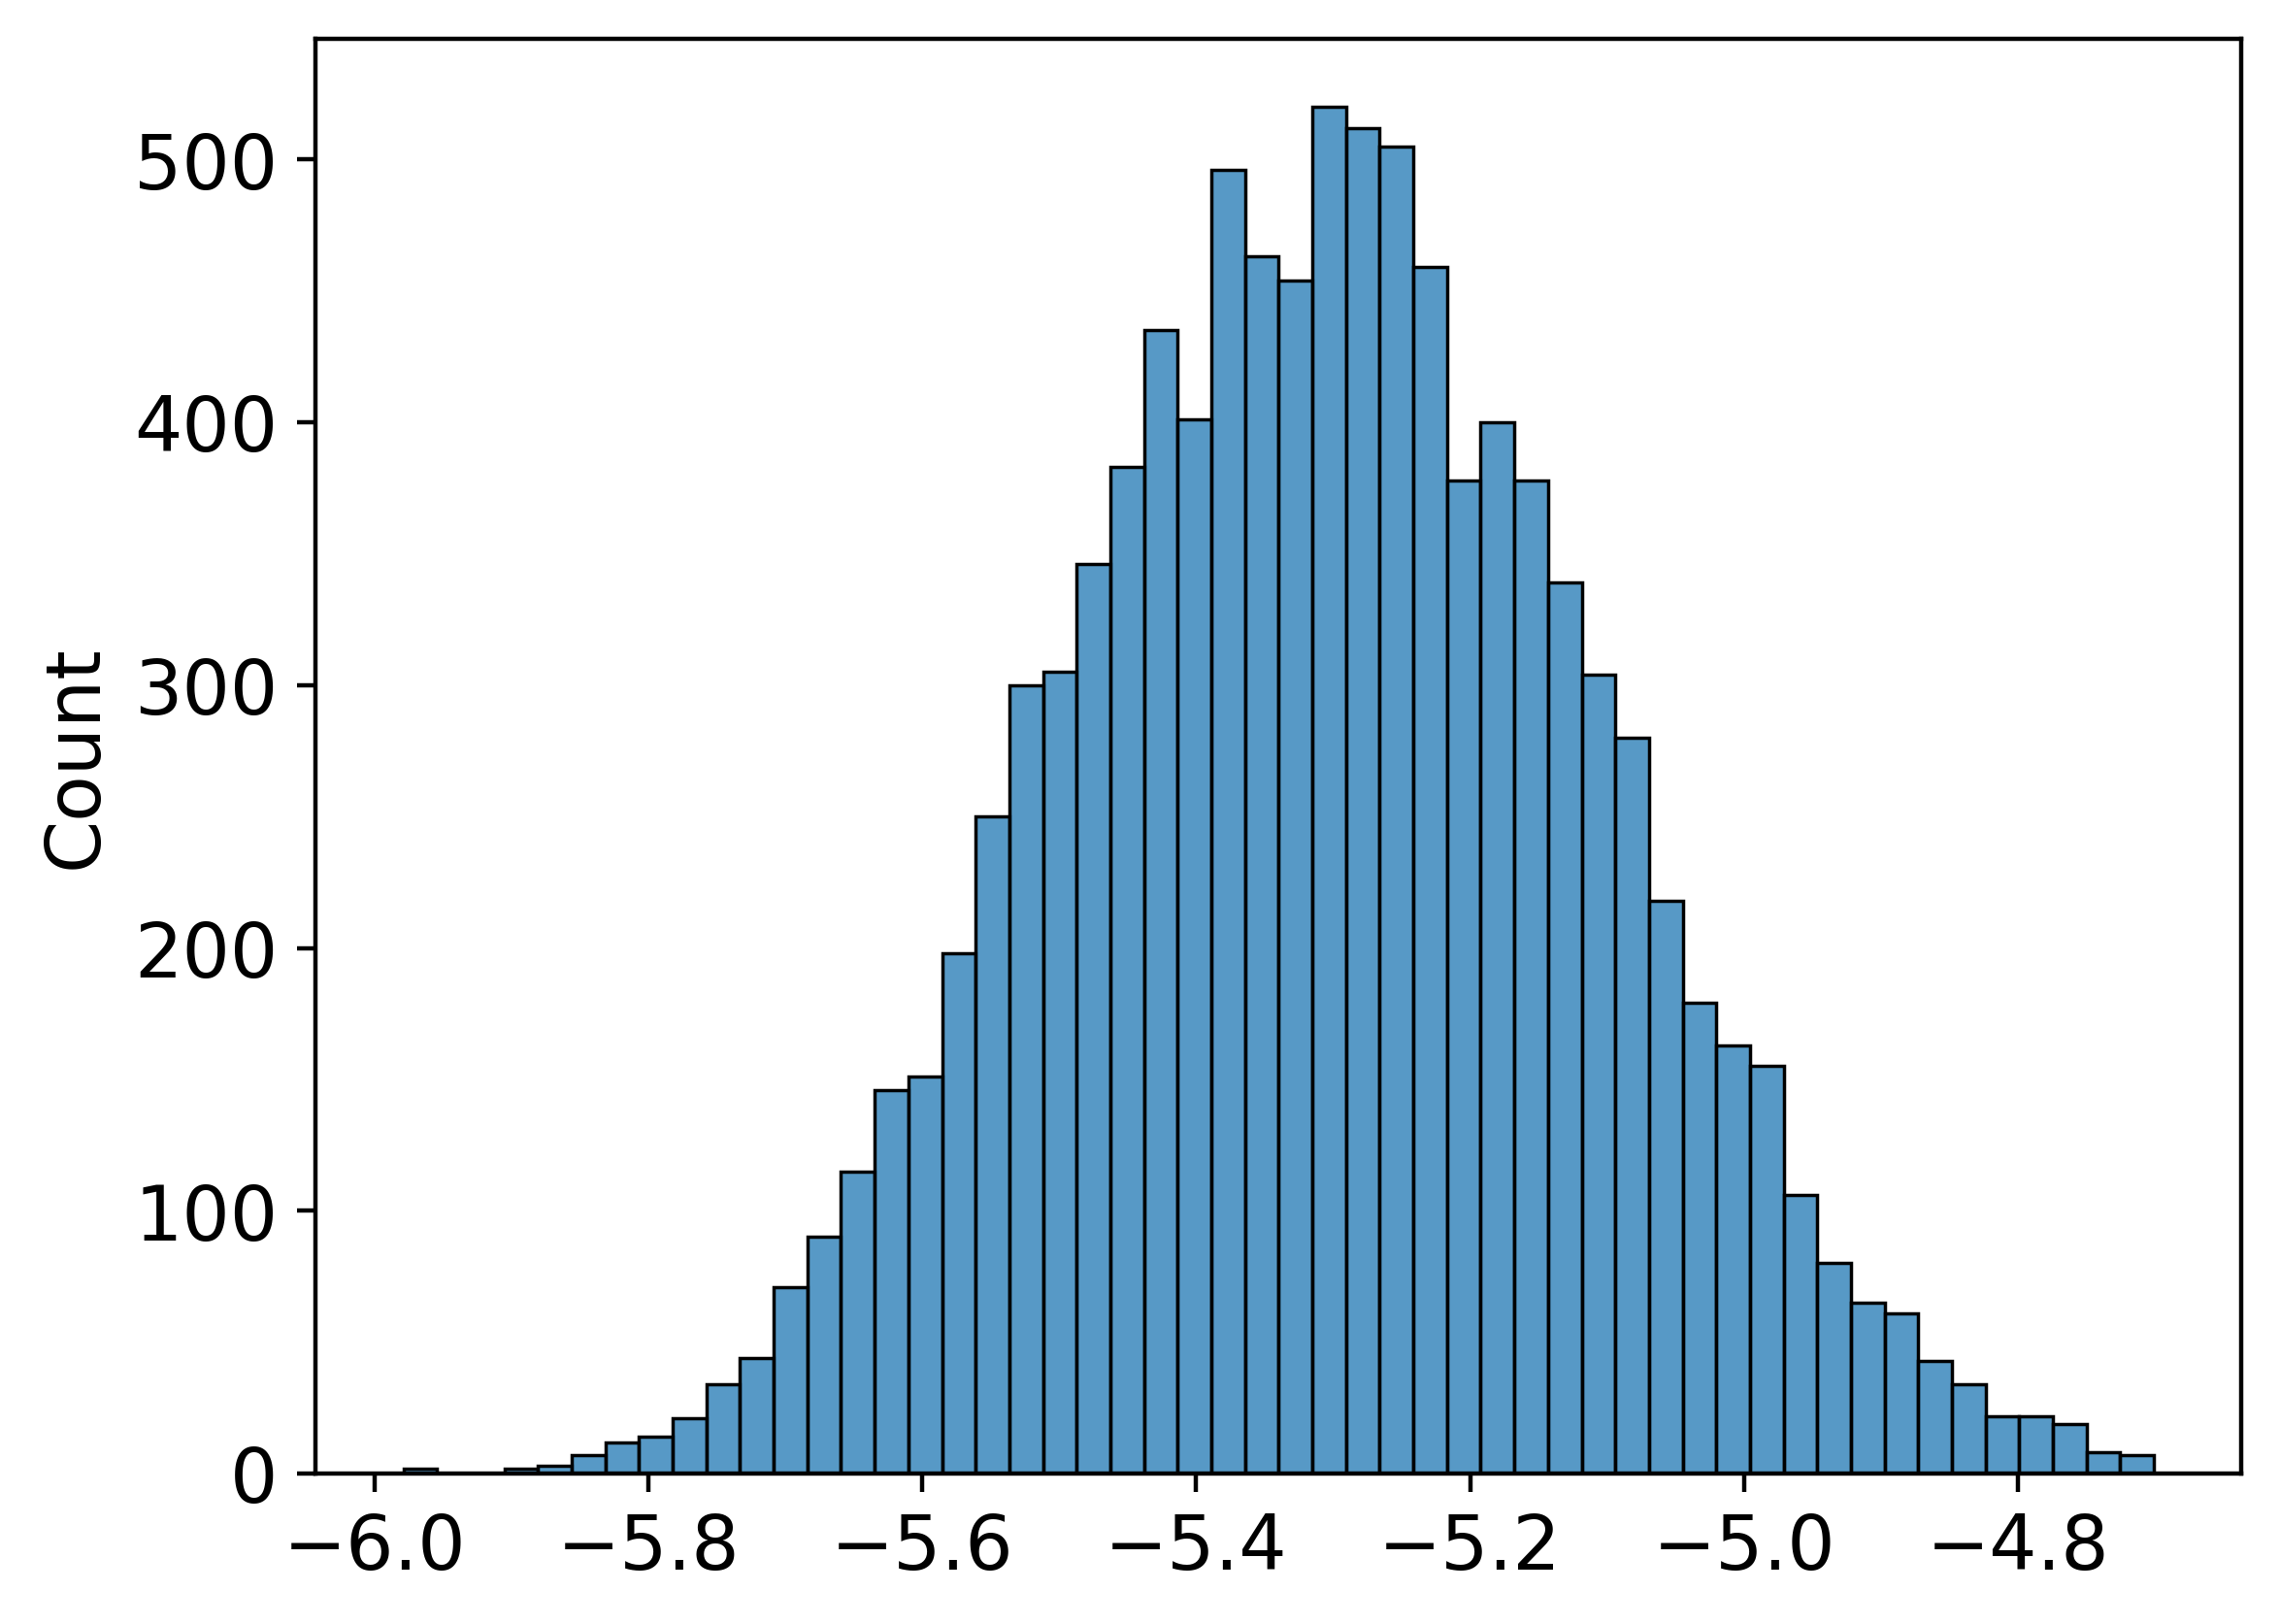

In [9]:
%%time
prior_min = np.log10(np.array([1e-2,1e-7,1e-8]))
prior_max = np.log10(np.array([1,1e-2,1e-2]))
prior = utils.BoxUniform(low=torch.tensor(prior_min), 
                         high=torch.tensor(prior_max))
posterior_chuong = pickle.load(open('posteriors/posterior_WF_30000_20.pkl', 'rb'))

op = CollectivePosterior(prior, X[:10], posterior_chuong, 1, epsilon=-40, n_eval=1000)
op.get_log_C()
histplot(op.sample_multimodal(n_samples=10000, k=1)[:,1])

Sampling: 100%|██████████| 10000/10000 [00:02<00:00, 4395.86it/s]


<Axes: ylabel='Count'>

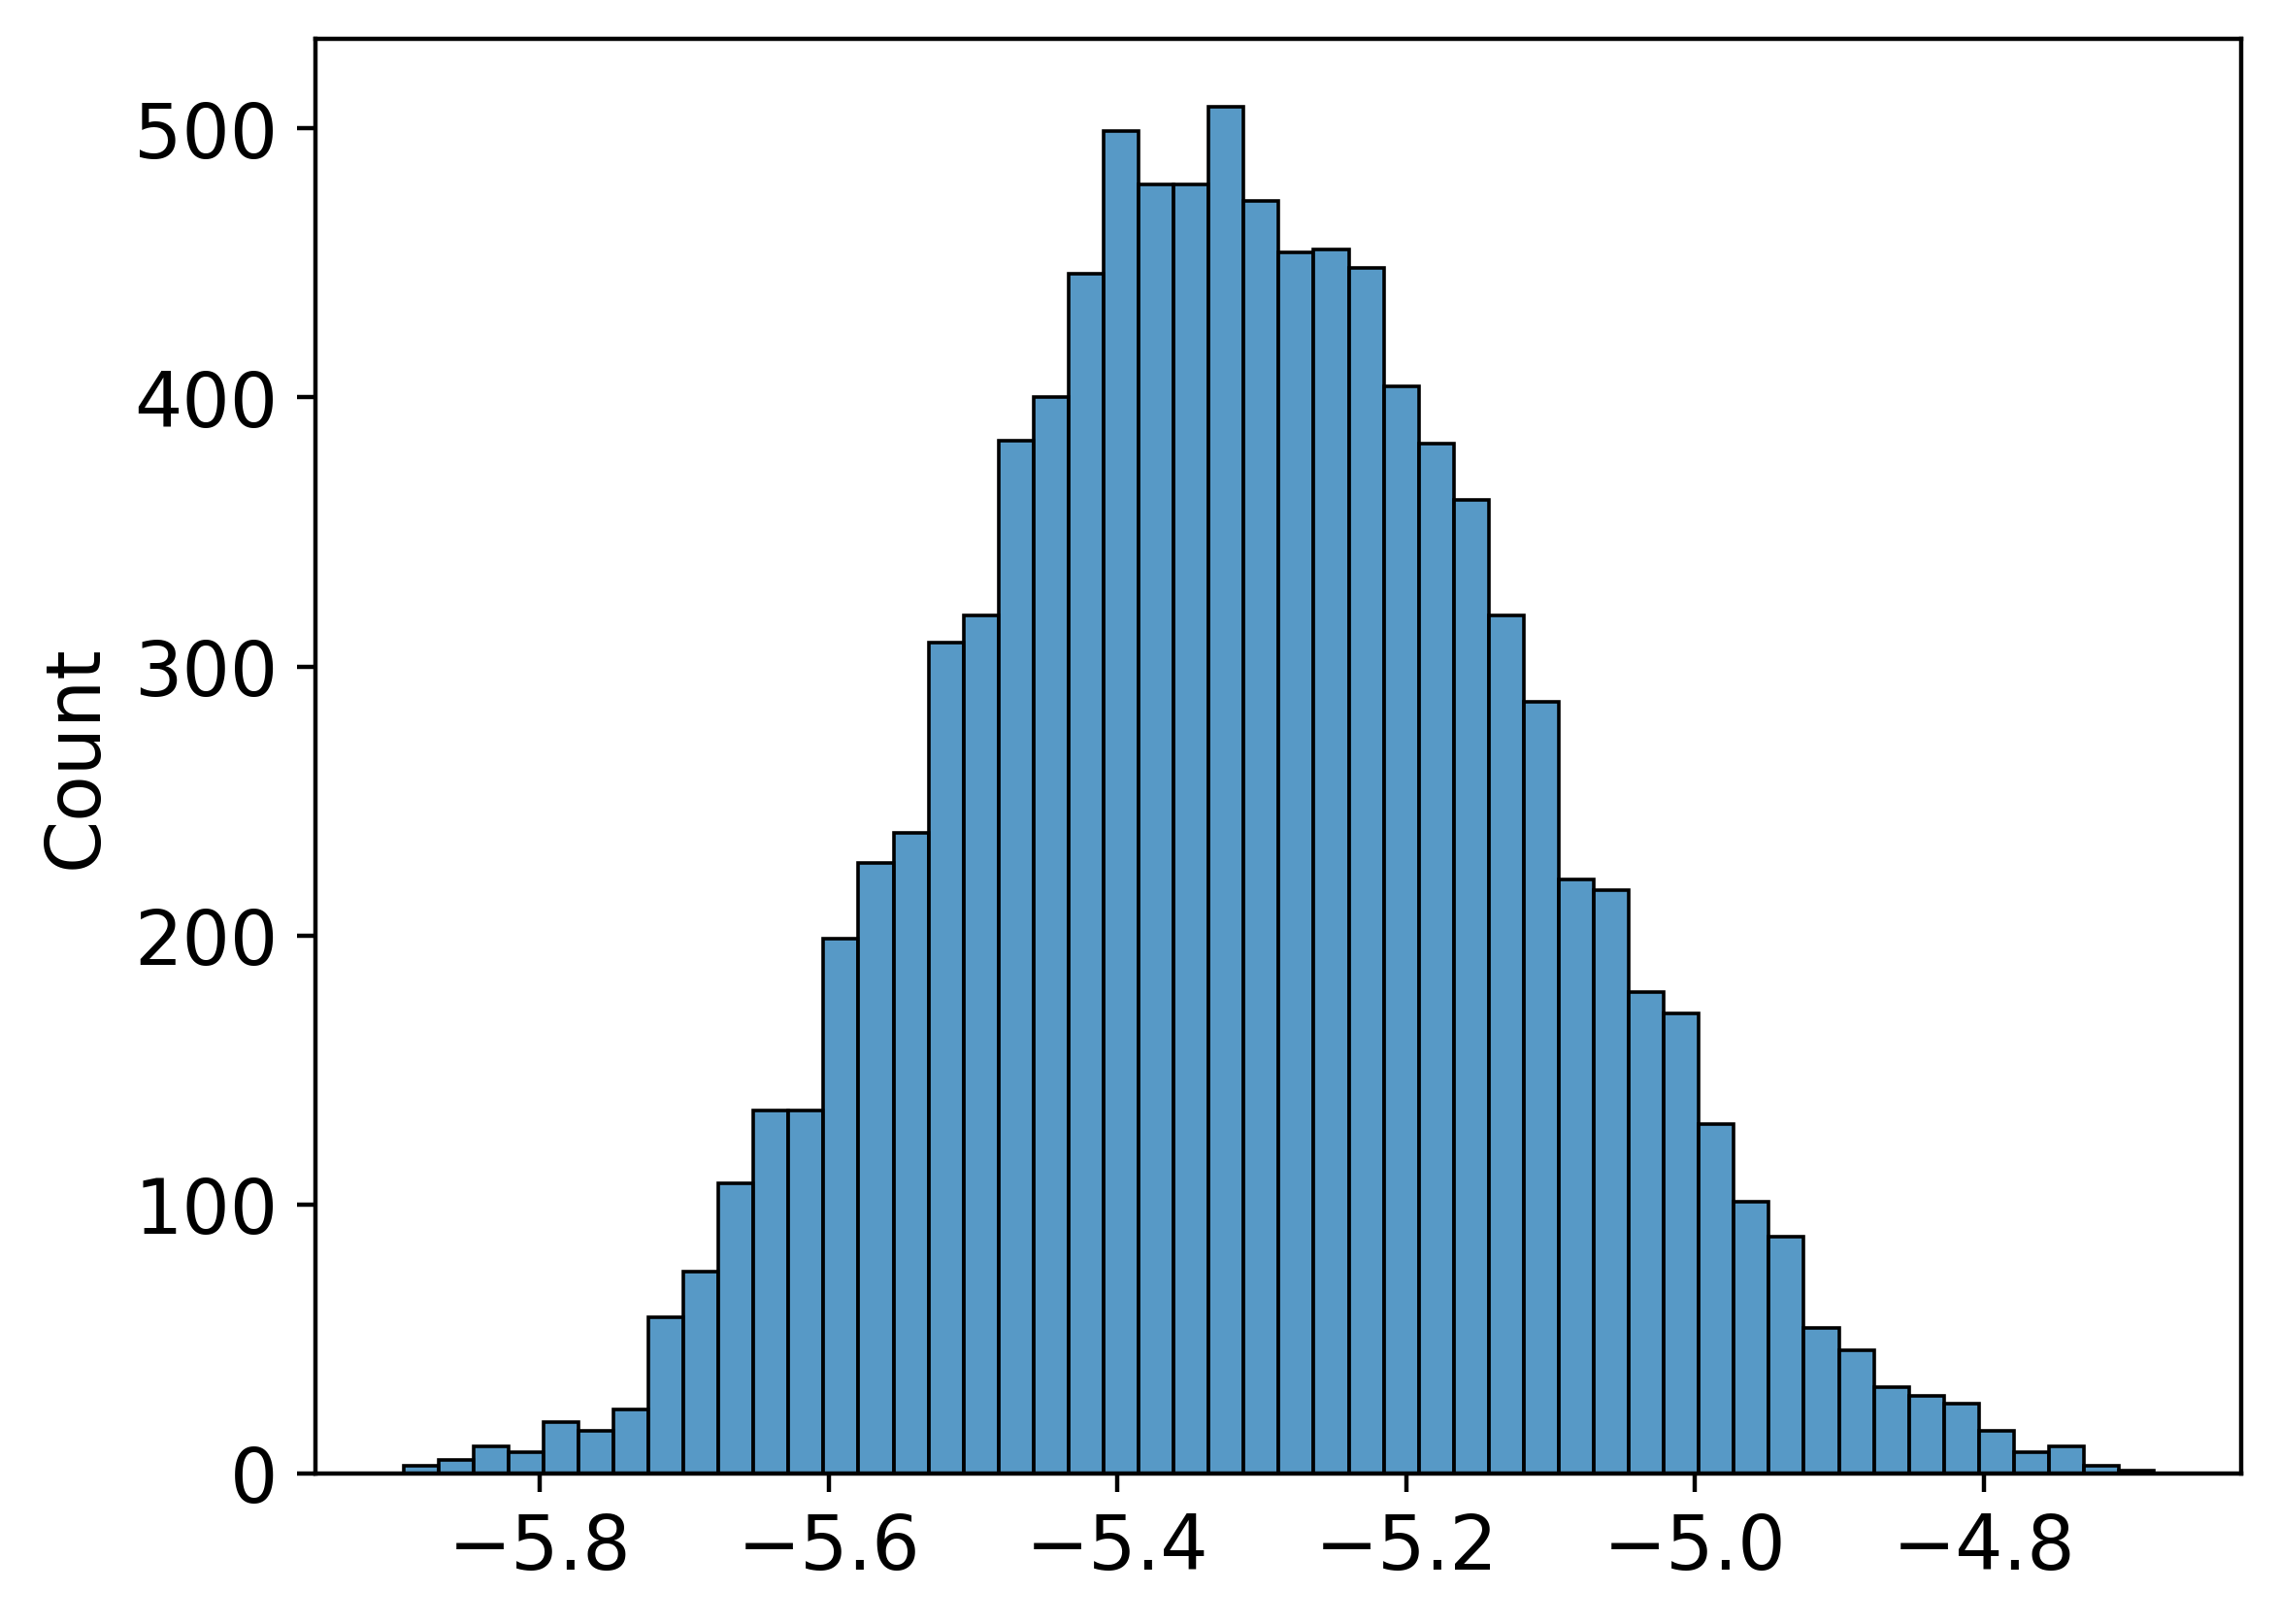

In [10]:
histplot(op.sample_unimodal(n_samples=10000)[:,1])